In [9]:
import os
import langgraph.graph as lg
from langchain_openai import ChatOpenAI
from langchain_community.utilities import SQLDatabase
from google.cloud import bigquery
from dotenv import load_dotenv
from langchain_core.messages import AIMessage, HumanMessage

In [10]:
from typing import TypedDict, List

class GraphState(TypedDict):
    question: str
    sql_query: str
    results: str
    initial_answer: str
    subquestions: List[str]
    corpus: List[str]


In [11]:
# ✅ Load environment variables (optional)
load_dotenv()

"""
# ✅ Set up Google BigQuery
key_path = os.getenv("GOOGLE_APPLICATION_CREDENTIALS")
if key_path and os.path.exists(key_path):
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = key_path
else:
    raise ValueError("❌ Google Cloud credentials not found!")

"""

client = bigquery.Client()
project_id = client.project  

# ✅ Connect SQLDatabase to BigQuery
db = SQLDatabase.from_uri(f"bigquery://{project_id}")

# ✅ Initialize LLM
llm = ChatOpenAI(model="gpt-4o", temperature=0)
llm_fast = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)



/Users/gretalerer/capstone_langgraph/venv/lib/python3.10/site-packages/google/cloud/bigquery/client.py:595: UserWarning: Cannot create BigQuery Storage client, the dependency google-cloud-bigquery-storage is not installed.
  warnings.warn(
/Users/gretalerer/capstone_langgraph/venv/lib/python3.10/site-packages/sqlalchemy_bigquery/_types.py:101: SAWarning: Did not recognize type 'GEOGRAPHY' of column 'distribution_center_geom'
  sqlalchemy.util.warn(
/Users/gretalerer/capstone_langgraph/venv/lib/python3.10/site-packages/sqlalchemy_bigquery/_types.py:101: SAWarning: Did not recognize type 'GEOGRAPHY' of column 'user_geom'
  sqlalchemy.util.warn(


In [12]:
def write_query(question: str) -> str:
    prompt = f"""
    You are an AI that generates SQL queries for a BigQuery database.

    **Database dialect:** {db.dialect}
    **Schema:** {db.get_table_info()}
    
    **User question:** "{question}"
    
    **Rules:**
    - You should write a query that answers the user question.
    - **Return only the SQL query.** No explanations.
    - The SQL query must be valid BigQuery SQL.
    - **Do not assume unknown columns.**
    
    Example Format:
    SELECT column FROM table WHERE condition;
    """
    raw_result = llm.invoke(prompt)

    sql_query = raw_result.content.strip().replace("```sql", "").replace("```", "").strip()
    return sql_query

def execute_query(sql_query: str) -> str:
    try:
        query_job = client.query(sql_query)
        results_df = query_job.result().to_dataframe()
        results_markdown = results_df.to_markdown()
        return results_markdown
    except Exception as e:
        return f"❌ Error: {str(e)}"

def summarize_result(sql_query: str, results: str) -> str:
    if "❌ Error" in results:
        return "I couldn't process the query due to an error."

    prompt = f"""
    You are a data analyst. Based on the following SQL query and its output, write a straightforward natural language answer that directly communicates the query result.

    **SQL Query:** 
    ```sql
    {sql_query}
    ```

    **Results:**
    {results}

    **Rules:**
    - Write in a conversational style.
    - Do not give an opinion or interpretation.

    Example:
    China was the country with the highest number of orders, with a total of 42,355 orders.
    """
    response = llm_fast.invoke(prompt)
    return response.content.strip()


In [17]:
def analyze_initial_sql_node(state):
    query = write_query(state["question"])
    results = execute_query(query)
    summary = summarize_result(query, results)
    print("\n🧾 Initial Summary:")
    print(summary)
    return {**state, "initial_answer": summary}



def generate_subquestions_node(state):
    prompt = f"""
    Based on the SQL summary below, generate 2 follow-up questions that could be answered using **only the internal e-commerce SQL database**.

    Your goal is to help the analyst understand the cause of the results or add more information. 

    Only ask questions that could be translated into valid SQL queries — for example, questions about:
    - Product categories
    - Number of orders
    - Average order value
    - Number of unique users
    - Regional patterns in the data

    ❌ Do not ask about external factors like culture, politics, or population size.

    Summary:
    {state['initial_answer']}
    """

    out = llm_fast.invoke(prompt).content.strip()
    subquestions = [line.strip("-• ") for line in out.splitlines() if line.strip()]

    print("\n🔍 Refined Subquestions (SQL-answerable only):")
    for i, subq in enumerate(subquestions, 1):
        print(f"{i}. {subq}")

    return {**state, "subquestions": subquestions}



def subquestion_analysis_node(state):
    summaries = []
    summaries.append(state["initial_answer"])
    for i, subq in enumerate(state["subquestions"], 1):
        print(f"\n🔄 Running subquestion {i}: {subq}")
        sql = write_query(subq)
        result = execute_query(sql)
        summary = summarize_result(sql, result)
        print(f"📝 Summary {i}: {summary}")
        summaries.append(summary)
    return {**state, "corpus": summaries}




In [18]:
graph = lg.StateGraph(GraphState)

graph.add_node("initial_query", analyze_initial_sql_node)
graph.add_node("generate_subquestions", generate_subquestions_node)
graph.add_node("subquestion_analysis", subquestion_analysis_node)

graph.add_edge("initial_query", "generate_subquestions")
graph.add_edge("generate_subquestions", "subquestion_analysis")

graph.set_entry_point("initial_query")
graph.set_finish_point("subquestion_analysis")

In [21]:
sql_graph_executor = graph.compile()

def run_graph(question: str):
    state = {"question": question}

    for step in sql_graph_executor.stream(state):
        for node_name, output_state in step.items():
            print(f"\n✅ Node completed: {node_name}")

            if "initial_answer" in output_state:
                print(f"\n🧾 Initial Summary:\n{output_state['initial_answer']}")

            if "subquestions" in output_state:
                print("\n🔍 Subquestions:")
                for i, q in enumerate(output_state["subquestions"], 1):
                    print(f"{i}. {q}")

            if "enriched_hop_answers" in output_state:
                print("\n📘 Subquestion Summaries:")
                for i, summary in enumerate(output_state["enriched_hop_answers"], 1):
                    print(f"\n🔁 Subquestion {i}:")
                    print(f"A: {summary}")

    # Final raw corpus output
    final_corpus = output_state.get("corpus", [])
    print("\n🧾 Raw Corpus (Python list):")
    print(final_corpus)

    return final_corpus

# Example usage
corpus = run_graph("What was the top selling product in January 2024?")


/Users/gretalerer/capstone_langgraph/venv/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1933: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



🧾 Initial Summary:
The product "Collections Etc - Tanya Circles V-Neck Dress" had the highest number of sales in January 2024, with a total of 2 sales.

✅ Node completed: initial_query

🧾 Initial Summary:
The product "Collections Etc - Tanya Circles V-Neck Dress" had the highest number of sales in January 2024, with a total of 2 sales.

🔍 Refined Subquestions (SQL-answerable only):
1. 1. What other products were purchased by customers who bought the "Collections Etc - Tanya Circles V-Neck Dress" in January 2024?
2. 2. How does the sales performance of the "Collections Etc - Tanya Circles V-Neck Dress" in January 2024 compare to the same month in the previous year?

✅ Node completed: generate_subquestions

🧾 Initial Summary:
The product "Collections Etc - Tanya Circles V-Neck Dress" had the highest number of sales in January 2024, with a total of 2 sales.

🔍 Subquestions:
1. 1. What other products were purchased by customers who bought the "Collections Etc - Tanya Circles V-Neck Dress"

/Users/gretalerer/capstone_langgraph/venv/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1933: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


📝 Summary 1: The query results show a list of product names that were purchased by users who also bought the "Collections Etc - Tanya Circles V-Neck Dress" in January 2024. The products in the list include Tight Leopard Print Leggings, Columbia Women's Benton Springs Full Zip Jacket, Levi's Women's 512 Bermuda, Patty Women Comfy Hooded Cable Knit Long Sleeve Jumper Tunic Top, and Plus Size White Open Front Cropped Bolero Shrug.

🔄 Running subquestion 2: 2. How does the sales performance of the "Collections Etc - Tanya Circles V-Neck Dress" in January 2024 compare to the same month in the previous year?


/Users/gretalerer/capstone_langgraph/venv/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1933: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


📝 Summary 2: In January 2024, the total sales for the product "Collections Etc - Tanya Circles V-Neck Dress" was $27.94.

✅ Node completed: subquestion_analysis

🧾 Initial Summary:
The product "Collections Etc - Tanya Circles V-Neck Dress" had the highest number of sales in January 2024, with a total of 2 sales.

🔍 Subquestions:
1. 1. What other products were purchased by customers who bought the "Collections Etc - Tanya Circles V-Neck Dress" in January 2024?
2. 2. How does the sales performance of the "Collections Etc - Tanya Circles V-Neck Dress" in January 2024 compare to the same month in the previous year?

🧾 Raw Corpus (Python list):
['The product "Collections Etc - Tanya Circles V-Neck Dress" had the highest number of sales in January 2024, with a total of 2 sales.', 'The query results show a list of product names that were purchased by users who also bought the "Collections Etc - Tanya Circles V-Neck Dress" in January 2024. The products in the list include Tight Leopard Print L

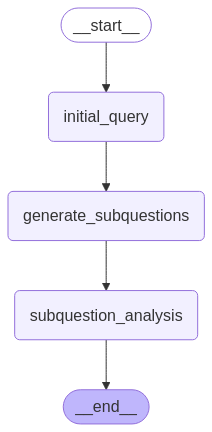

In [20]:
from IPython.display import Image, display


display(Image(sql_graph_executor.get_graph().draw_mermaid_png()))